<a href="https://colab.research.google.com/github/sagiv-bar/sagiv-bar.github.io/blob/main/Gaussian_Noise_Estimation_and_Denoising_Using_BM3D_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install bm3d

import os, sys
from pathlib import Path
import cv2
import numpy as np
import scipy
from scipy.stats.distributions import chi2
import matplotlib.pyplot as plt
import bm3d
from scipy import stats
from skimage.metrics import peak_signal_noise_ratio, structural_similarity, mean_squared_error
from scipy.stats import pearsonr

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


# Blind Noise Estimation & BM3D Denoising

**Sagiv Bar** · [github.com/sagiv-bar](https://github.com/sagiv-bar) · [LinkedIn](https://www.linkedin.com/in/sagiv-bar)

---

### The problem

BM3D is one of the strongest image denoisers available, but it requires the noise standard
deviation `sigma` as an input — and on a real image you do not know it. This notebook estimates
`sigma` blindly, from the noisy image alone, and then uses it to drive BM3D.

### The method

1. **Patch decomposition** — split the image into overlapping 6x6 patches.
2. **Texture scoring** — score each patch with a gradient texture index (Sobel, `compute_patches`).
   Flat patches carry noise; textured patches carry signal.
3. **Initial estimate** — pool the per-patch variances of the flat patches and estimate `sigma`
   via a chi-square confidence bound (`chi2.ppf(T, df=DOF)`).
4. **Threshold calibration** — synthesise pure noise at the current `sigma` estimate and take the
   maximum texture index over its patches as the flat/textured threshold (`step_4`).
5. **Iterate** — re-select flat patches under the new threshold and re-estimate, until the relative
   change in variance falls below `delta = 1e-3`.
6. **Denoise** — feed the converged `sigma` to BM3D hard-thresholding.

### Evaluation

Reconstruction is scored against the clean reference with **MSE, SNR, PSNR, SSIM** and **Pearson
correlation** (`noise_metrics`).

### Reproducing

Point `images_dir` at a folder of images, set `sigma` in the parameters cell to the noise level
you want to synthesise, and run top to bottom.

In [ ]:
images_dir = Path("/p")
images_path = list(images_dir.rglob("*.jpg"))

In [ ]:
def add_gaussian_noise(img, sigma):
    img_norm = img
    noise = np.random.normal(0, sigma, img.shape)
    result = img_norm + noise
    return result

In [ ]:
def split_to_patches(img, path_size=(6,6)):
    patches = []
    p = []
    for i in range(0, img.shape[0]-(path_size[0]+2)):
        for j in range(0, img.shape[1]-(path_size[1]+2)):
            patch = img[i:i+path_size[0], j:j+path_size[1]]
            patches.append(patch)
            p.append([i,j])
    return  np.array(patches), np.array(p)

In [ ]:
def compute_grads(img):
    scale = 1
    delta = 0
    ddepth = cv2.CV_16S
    grad_x = cv2.Sobel(img, ddepth, 1, 0, ksize=3, scale=scale, delta=delta, borderType=cv2.BORDER_DEFAULT)
    grad_y = cv2.Sobel(img, ddepth, 0, 1, ksize=3, scale=scale, delta=delta, borderType=cv2.BORDER_DEFAULT)
    return grad_x, grad_y

In [ ]:
def compute_patches(patches):
    patches_noise = []
    for i in range(patches.shape[0]):
        patch = patches[i]
        grad_x, grad_y = compute_grads(patch)
        noise = np.sum(np.abs(grad_x+grad_y))
        patches_noise.append(noise)
    return np.array(patches_noise)

# algorithm

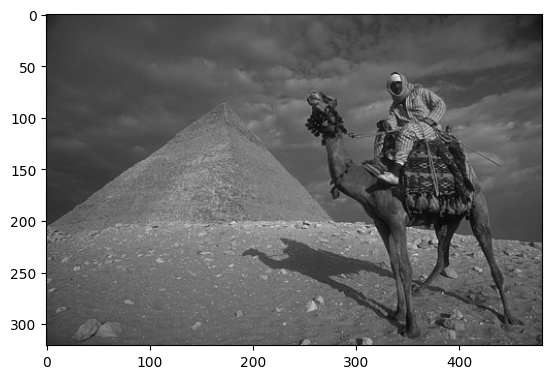

In [ ]:
img_gray = cv2.imread(str(images_path[0]), 0) ## choose one of your picture
plt.imshow(img_gray, cmap="gray")

In [ ]:
## Insert the parameters you want , its parameter of the article
iter = 100
delta = 1e-3
T = 1 - np.exp(-6)
sigma = 20
noise_img = add_gaussian_noise(img_gray, sigma)

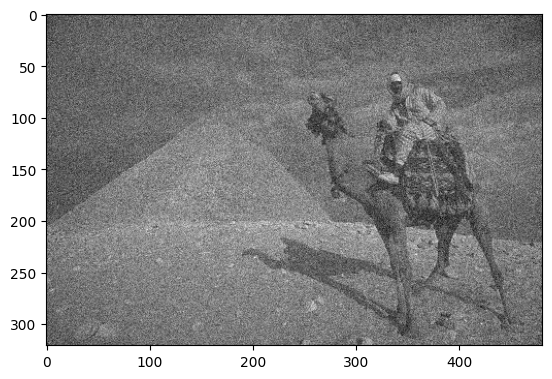

In [ ]:
plt.imshow(noise_img, cmap="gray")
plt.show()

In [ ]:
def step_4(std_est, shape):
    var = std_est**2
    N_im = np.random.normal(0, std_est, shape)
    N_patches, _ = split_to_patches(N_im)
    N_GTIs = compute_patches(N_patches);
    epsilon_lamda = np.max(N_GTIs)
    return epsilon_lamda

def noise_estimation(noise_img):
    # step 1
    patches, p = split_to_patches(noise_img)
    # step 2
    epsilon_k = compute_patches(patches)
    print("Epsilon_K",np.max(epsilon_k),epsilon_k)
    # step 3
    patches_mean, patches_std = np.mean(patches, axis=(1,2)), np.std(patches, axis=(1,2))
    DOF = patches_std.shape[0]
    init_std_est = np.sqrt(sum(patches_std**2) / chi2.ppf(T, df=DOF));
    # step 4
    epsilon_lamda = step_4(init_std_est, noise_img.shape)
    print("Epsilon_lamda",epsilon_lamda)
    # step 5
    flat_patches = patches[epsilon_k < epsilon_lamda]
    std_est_list = [init_std_est]
    for i in range(iter):
        std_est = std_est_list[-1]
        DOF = len(flat_patches)
        patches_mean, patches_std = np.mean(flat_patches, axis=(1,2)), np.std(flat_patches, axis=(1,2))
        std_est_t1 = np.sqrt(sum(patches_std**2) / chi2.ppf(T, df=DOF));
        std_est_list.append(std_est_t1)

        phi = abs(std_est_t1**2 - std_est**2) / abs(std_est**2);
        print(std_est_t1, phi)
        if phi <= delta:
            break

        epsilon_lamda = step_4(std_est_t1, noise_img.shape)
        flat_patches = patches[epsilon_k < epsilon_lamda]

    return std_est_list

In [ ]:
std_est_list = noise_estimation(noise_img)

final_std_est = std_est_list[-1]
final_std_est

Epsilon_K 9678 [2385 2218 2517 ... 2588 2476 2788]
Epsilon_lamda 5346
21.994800112209628 0.014202130923488382
22.00806901231447 0.0012069127640243218
21.994800112209628 0.0012054578815206209
21.95875385868358 0.003275021012171484
21.950552520814185 0.0007468371265740872


21.950552520814185

In [ ]:
denoised_image = bm3d.bm3d(noise_img, sigma_psd=final_std_est, stage_arg=bm3d.BM3DStages.HARD_THRESHOLDING)

In [ ]:
def plot_seg_result(img, noise_img, denoised_image):
    plt.figure(figsize=(20,20))
    plt.subplot(131)
    plt.title('Original Image')
    plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    plt.subplot(132)
    plt.title('noised img')
    plt.imshow(noise_img, cmap="gray", vmin=0, vmax=255)
    plt.subplot(133)
    plt.imshow(denoised_image, cmap="gray", vmin=0, vmax=255)
    plt.title('denoised image')

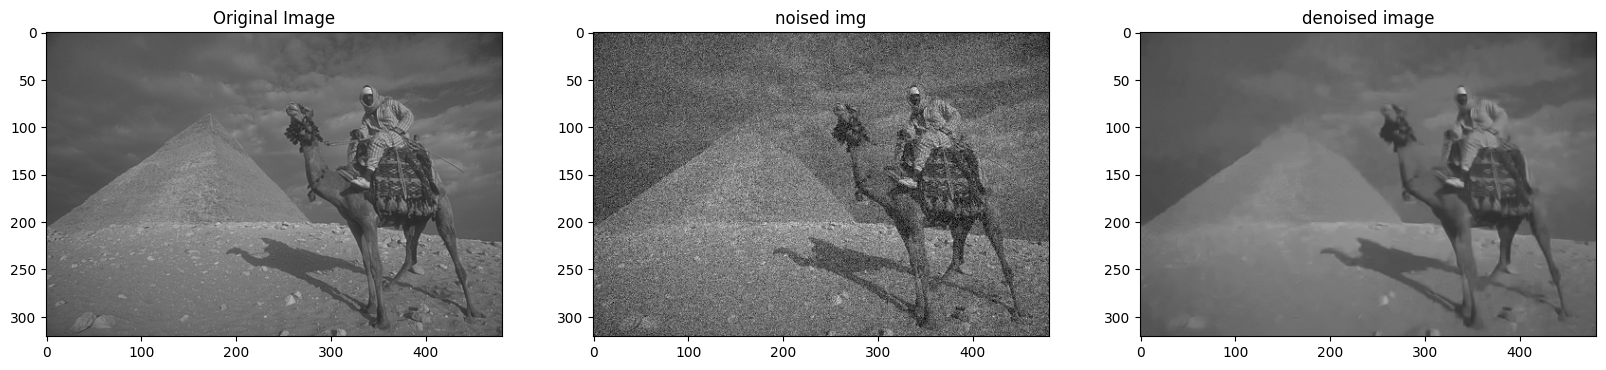

In [ ]:
plot_seg_result(img_gray, noise_img, denoised_image)



In [ ]:
def noise_metrics(img_gray, denoised_image):

    MSE = mean_squared_error(img_gray, denoised_image)
    SNR = 10 * np.log10(np.mean(np.square(img_gray)) / MSE)
    PSNR = peak_signal_noise_ratio(img_gray, denoised_image, data_range=img_gray.max())
    SSIM = structural_similarity(img_gray, denoised_image, data_range=img_gray.max())
    CORR, _ = pearsonr(img_gray.flatten(), denoised_image.flatten())
    return MSE, SNR, PSNR,SSIM, CORR

In [ ]:
noise_metrics(img_gray, denoised_image)

(58.66443932783718,
 2.526385008076244,
 29.43676790030271,
 0.7492100791658486,
 0.9381861557942808)